### VidTok 检查工具

Frame 0 tokens:
  Shape: (32, 32)
  Min: 562, Max: 261912


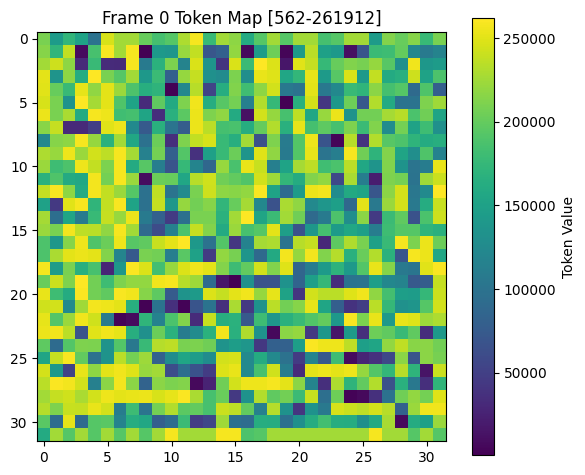

In [8]:
# 查看第 0 帧的 token
frame_idx = 0
frame_tokens = tokens[0, frame_idx]  # [32, 32]

print(f"Frame {frame_idx} tokens:")
print(f"  Shape: {frame_tokens.shape}")
print(f"  Min: {frame_tokens.min()}, Max: {frame_tokens.max()}")

# 可视化
plt.figure(figsize=(6, 5))
plt.imshow(frame_tokens, cmap='viridis')
plt.title(f'Frame {frame_idx} Token Map [{frame_tokens.min()}-{frame_tokens.max()}]')
plt.colorbar(label='Token Value')
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
data = np.load("/nfs/yanzhang.ljx/workspace/VidTok/output/example2.npy", allow_pickle=True).item()
print(data['tokens'])


[[[[[ 1.8056066   1.5957428   1.5832651  ... -2.0017626  -2.102239
     -2.041568  ]
    [ 1.7244263   1.5969689   1.7212783  ... -2.0949054  -2.230036
     -1.8903798 ]
    [ 1.94472     1.5784374   1.6849393  ... -2.2122335  -2.0932055
     -1.9765282 ]
    ...
    [ 1.6238645   1.4282664   1.9705335  ... -1.4559152  -1.3667483
     -1.408996  ]
    [ 1.492187    1.5212772   1.5188782  ... -0.95310277 -1.0849385
     -0.47318333]
    [ 1.6315529   1.6513108   1.5042553  ... -1.3930793  -1.5007898
     -1.4077963 ]]

   [[ 1.6864872   1.5848478   1.4943511  ... -2.2231393  -2.0736399
     -1.7796687 ]
    [ 1.7247521   1.537623    1.549918   ... -2.126562   -2.350511
     -2.0111487 ]
    [ 1.3344196   1.7918869   1.5469245  ... -2.2619689  -1.8525087
     -1.9426628 ]
    ...
    [ 1.4666092   1.5606693   1.8137016  ... -0.97538877 -0.8862529
     -0.9269044 ]
    [ 1.4059508   1.5175914   1.6608406  ... -1.4326057  -1.3176498
     -1.268412  ]
    [ 1.2945791   1.5207201   1.2284571

In [7]:
import numpy as np
data = np.load("/nfs/yanzhang.ljx/workspace/VidTok/output/example2.npy", allow_pickle=True).item()
print(data['tokens'].shape)

(1, 16, 396, 14, 32)


In [ ]:
import decord
decord.bridge.set_bridge('torch')
video_reader = decord.VideoReader('assets/example.mp4', num_threads=0)
total_frames = len(video_reader)
fps = video_reader.get_avg_fps()
print(f'Total frames: {total_frames}')
print(f'FPS: {fps}')    

Total frames: 136
FPS: 30.0


In [ ]:
import torch
import torch.nn as nn

class LightVideoProjector(nn.Module):
    """
    将 VQ-VAE 特征 [B, C=16, T, H, W] 映射为 [B, T, D_llm]
    设计：空间-通道注意力引导的加权池化
    """
    def __init__(self, vq_dim=16, llm_dim=4096, max_t=375, use_temporal_pe=True):   # max_t = 60 * 25 / 4 = 375
        super().__init__()
        self.max_t = max_t
        self.use_temporal_pe = use_temporal_pe
        
        # 通道注意力 (SE变体)
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(vq_dim, vq_dim // 2, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(vq_dim // 2, vq_dim, kernel_size=1),
            nn.Sigmoid()
        )
        # 使用 7x7 大卷积核捕获主体结构上下文
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(1, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )
        
        # 时间位置编码
        if use_temporal_pe:
            self.temporal_embed = nn.Parameter(torch.empty(max_t, llm_dim))
            nn.init.normal_(self.temporal_embed, std=0.02)
            
        # 分布归一化 (VQ-VAE latent 方差大)
        self.norm = nn.LayerNorm(vq_dim)
        
        # mlp2x_gelu (16 -> 4096 上采样)
        self.projector = nn.Sequential(
            nn.Linear(vq_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim)
        )

    def forward(self, x):
        """
        Args:
            x: [B, 16, T, H, W]
        Returns:
            out: [B, T, D_llm]
        """
        B, C, T, H, W = x.shape
        
        # Step 1: 调整维度顺序，便于逐帧处理 [B, C, T, H, W] -> [B, T, C, H, W]
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        x_flat = x.view(B * T, C, H, W)
        # 通道注意力
        ca_weights = self.channel_attn(x_flat)
        x_flat = x_flat * ca_weights
        # 空间注意力
        sa_weights = self.spatial_attn(x_flat.mean(dim=1, keepdim=True))
        
        # 按显著性分数聚合，避免背景噪声稀释人物特征
        sa_norm = sa_weights / (sa_weights.sum(dim=(-2, -1), keepdim=True) + 1e-6)
        x_pooled = (x_flat * sa_norm).sum(dim=(-2, -1))  # [B*T, C]
        
        # 维度对齐
        x = x_pooled.view(B, T, C)
        x = self.norm(x)
        x = self.projector(x)  # [B, T, D_llm]
        
        # 注入时间位置编码
        if self.use_temporal_pe:
            T_safe = min(T, self.max_t)
            x = x + self.temporal_embed[:T_safe]
            
        return x


In [ ]:
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. 初始化
device = "cpu"
projector = LightVideoProjector(vq_dim=16, llm_dim=4096, max_t=375).to(device)
# llm = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-7B").to(device)
# tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")

# 2. 模拟你的 VQ-VAE 输出
data = np.load("/nfs/yanzhang.ljx/workspace/VidTok/output/example.npy", allow_pickle=True).item()
vq_feats = torch.from_numpy(data['tokens']).to(device)

# 3. 投影为 [1, 396, 4096]
vis_tokens = projector(vq_feats)
print(f"输出形状: {vis_tokens.shape}")

# # 4. 文本 Prompt
# prompt = "描述视频中的动作序列。"
# text_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
# text_embeds = llm.get_input_embeddings()(text_ids)  # [1, L_txt, 4096]

# # 5. 拼接视觉与文本
# # 假设 <video> 占位符已替换，此处直接拼接
# final_embeds = torch.cat([vis_tokens, text_embeds], dim=1)  # [1, 396+L_txt, 4096]
# attn_mask = torch.ones(final_embeds.shape[:2], dtype=torch.bool, device=device)

# # 6. 前向传播
# with torch.no_grad():
#     outputs = llm(inputs_embeds=final_embeds, attention_mask=attn_mask, return_dict=True)
#     print(f"输出形状: {outputs.logits.shape}")  # [1, 396+L_txt, vocab_size]

输出形状: torch.Size([1, 32, 4096])
